# PROJECT TITLE:
# Comparative Analysis of Machine Learning Models for Early Diabetes Detection.

# GROUP MEMBERS:
- ##### UMAR FARUK IBRAHIM-------------------------------471118017
- ##### MUHAMMAD ISHTIYAQ AHMAD HAMZA--------------------471118008

In [22]:
# Importing the Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Data Source

This dataset is taken originally from the National Institute of Diabetes, Digestive and Kidney Diseases.

The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain
diagnostic measurements included in the dataset. Several constraints were placed on the selection of these
instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian
heritage.

The dataset consists of several medical predictor variables and one target variable, Outcome. Predictor
variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

There are 768 observations and 8 independent variables in the dataset. The target variable indicates the test
result of the patient. It is 1 when the test result is positive and 0 when the test result is negative.

In [3]:
# Loading the Data and viewing the top five (5) Observations
diabetes_data = pd.read_csv("pima-indian-diabetes-dataset.csv")
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Viewing the last five (5) Observations
diabetes_data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


# Data Characteristics:

In [5]:
print("The Columns of the Data are: ")
diabetes_data.columns

The Columns of the Data are: 


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
# Providing a short description of the dataset
print("Some of the Basic Information about the dataset:\n")
diabetes_data.info()

Some of the Basic Information about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Printing the shape of the dataset
print("The Shape of the dataset is: ", diabetes_data.shape)

The Shape of the dataset is:  (768, 9)


In [8]:
# Printing a summary statistics of the data, which include mean, mode, etc
print("The Summary Statistics of the Data is as follows:")
diabetes_data.describe().transpose()

The Summary Statistics of the Data is as follows:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Data Exploration and Preprocessing: Exploration Data Analysis(EDA)

In [9]:
# Checking for missing values
print("For each Feature, Here are the number of Missing Values")
diabetes_data.isnull().sum()

For each Feature, Here are the number of Missing Values


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
# Counting the total number of observations for each feature
print("For Each Feature, Here are the total number of observations:")
diabetes_data.count()

For Each Feature, Here are the total number of observations:


Pregnancies                 768
Glucose                     768
BloodPressure               768
SkinThickness               768
Insulin                     768
BMI                         768
DiabetesPedigreeFunction    768
Age                         768
Outcome                     768
dtype: int64

In [11]:
diabetes_data.count() == 0

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

In [12]:
# Countion the number of Negative(0) and Positive(1) observations
print("Target Variable Distribution (Outcome):")
print(diabetes_data['Outcome'].value_counts(normalize=True))

Target Variable Distribution (Outcome):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


This means that almost 65% of the data contains people that there result is NEGATIVE(0) and about 35% there results is POSITIVE(1)

# Visualization

C:\Users\ACER NITRO 5\AppData\Local\Temp\ipykernel_13620\4071556108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=diabetes_data, palette='Set2')


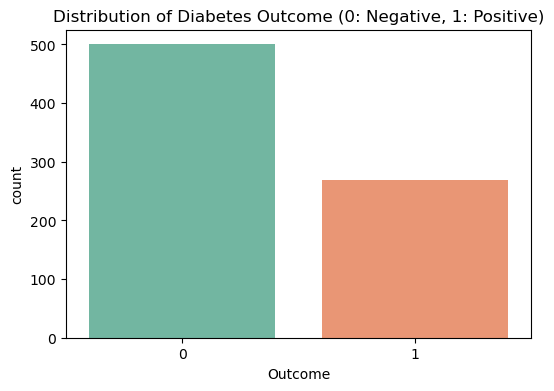

In [13]:
# Visualizing the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=diabetes_data, palette='Set2')
plt.title('Distribution of Diabetes Outcome (0: Negative, 1: Positive)')
plt.show()

<Axes: xlabel='BMI', ylabel='Count'>

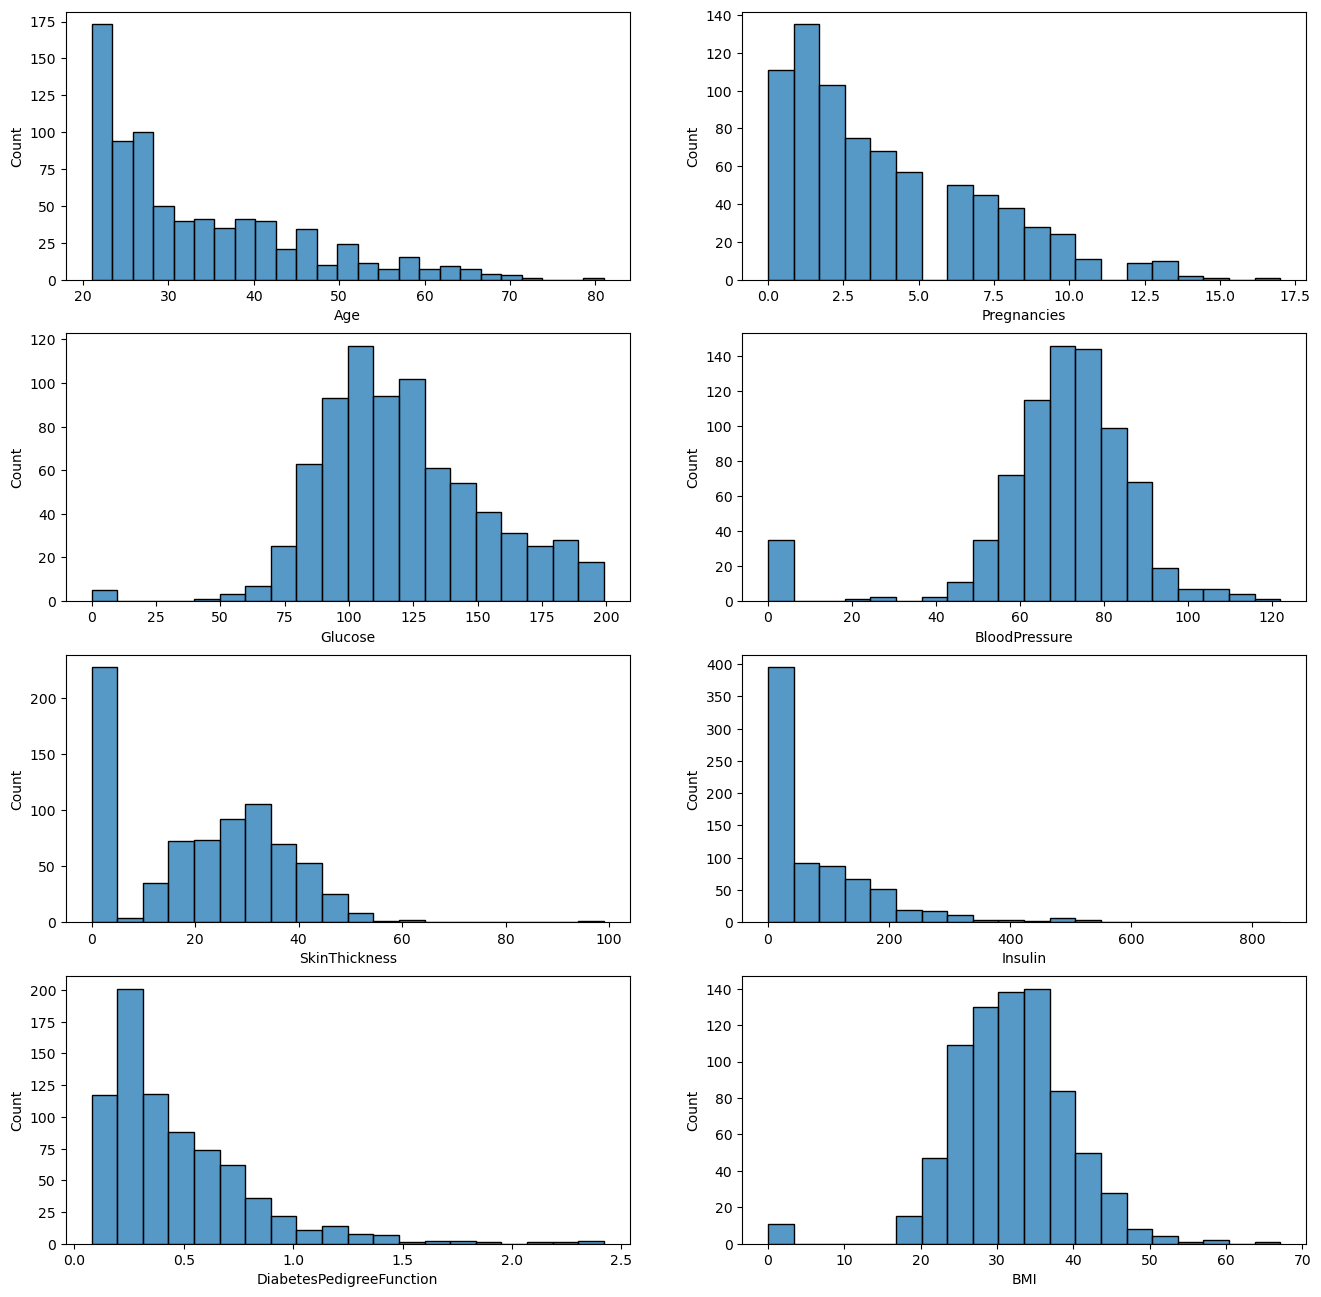

In [14]:
fig, ax = plt.subplots(4,2, figsize=(16,16))
sns.histplot(diabetes_data.Age, bins = 25, ax=ax[0,0])
sns.histplot(diabetes_data.Pregnancies, bins = 20, ax=ax[0,1])
sns.histplot(diabetes_data.Glucose, bins = 20, ax=ax[1,0])
sns.histplot(diabetes_data.BloodPressure, bins = 20, ax=ax[1,1])
sns.histplot(diabetes_data.SkinThickness, bins = 20, ax=ax[2,0])
sns.histplot(diabetes_data.Insulin, bins = 20, ax=ax[2,1])
sns.histplot(diabetes_data.DiabetesPedigreeFunction, bins = 20, ax=ax[3,0])
sns.histplot(diabetes_data.BMI, bins = 20, ax=ax[3,1])

##### From the Above Visuals, we can observe that there are observations that have zero's which are not suppose to be, in cloumns like: 'Glucose','BloodPressure','SkinThickness','Insulin', and 'BMI'.
##### So now, we have to deal it with them inorder to avoid our trained model inaccurate predictions.

There are no missing values in the dataset but if we observe the dataset now as from our visuals above, we can see that lots of features have 0 values.

For example in Columns: 'Glucose','BloodPressure','SkinThickness','Insulin', and 'BMI', having 0 for those features make no sense like having 0 bloodpressure or BMI etc.

It appears as if zero was used as a imputer value in original data for missing values. We can treat them as
missing and impute with proper values.

So, to count the number of zeros, it is better we replace them with NaN because counting them would be easier and also be replaced with
suitable values.

In [15]:
# Let's Copy the data so that we can leave the original as it is for reference
diabetes_data_copy = diabetes_data.copy()

# Replacing zeroes with Nan value
diabetes_data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diabetes_data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

## showing the count of Nans
print(diabetes_data_copy.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


C:\Users\ACER NITRO 5\AppData\Local\Temp\ipykernel_13620\4137698749.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes_data_copy.Age, bins = 25, ax=ax[0,0])
C:\Users\ACER NITRO 5\AppData\Local\Temp\ipykernel_13620\4137698749.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes_

<Axes: xlabel='BMI', ylabel='Density'>

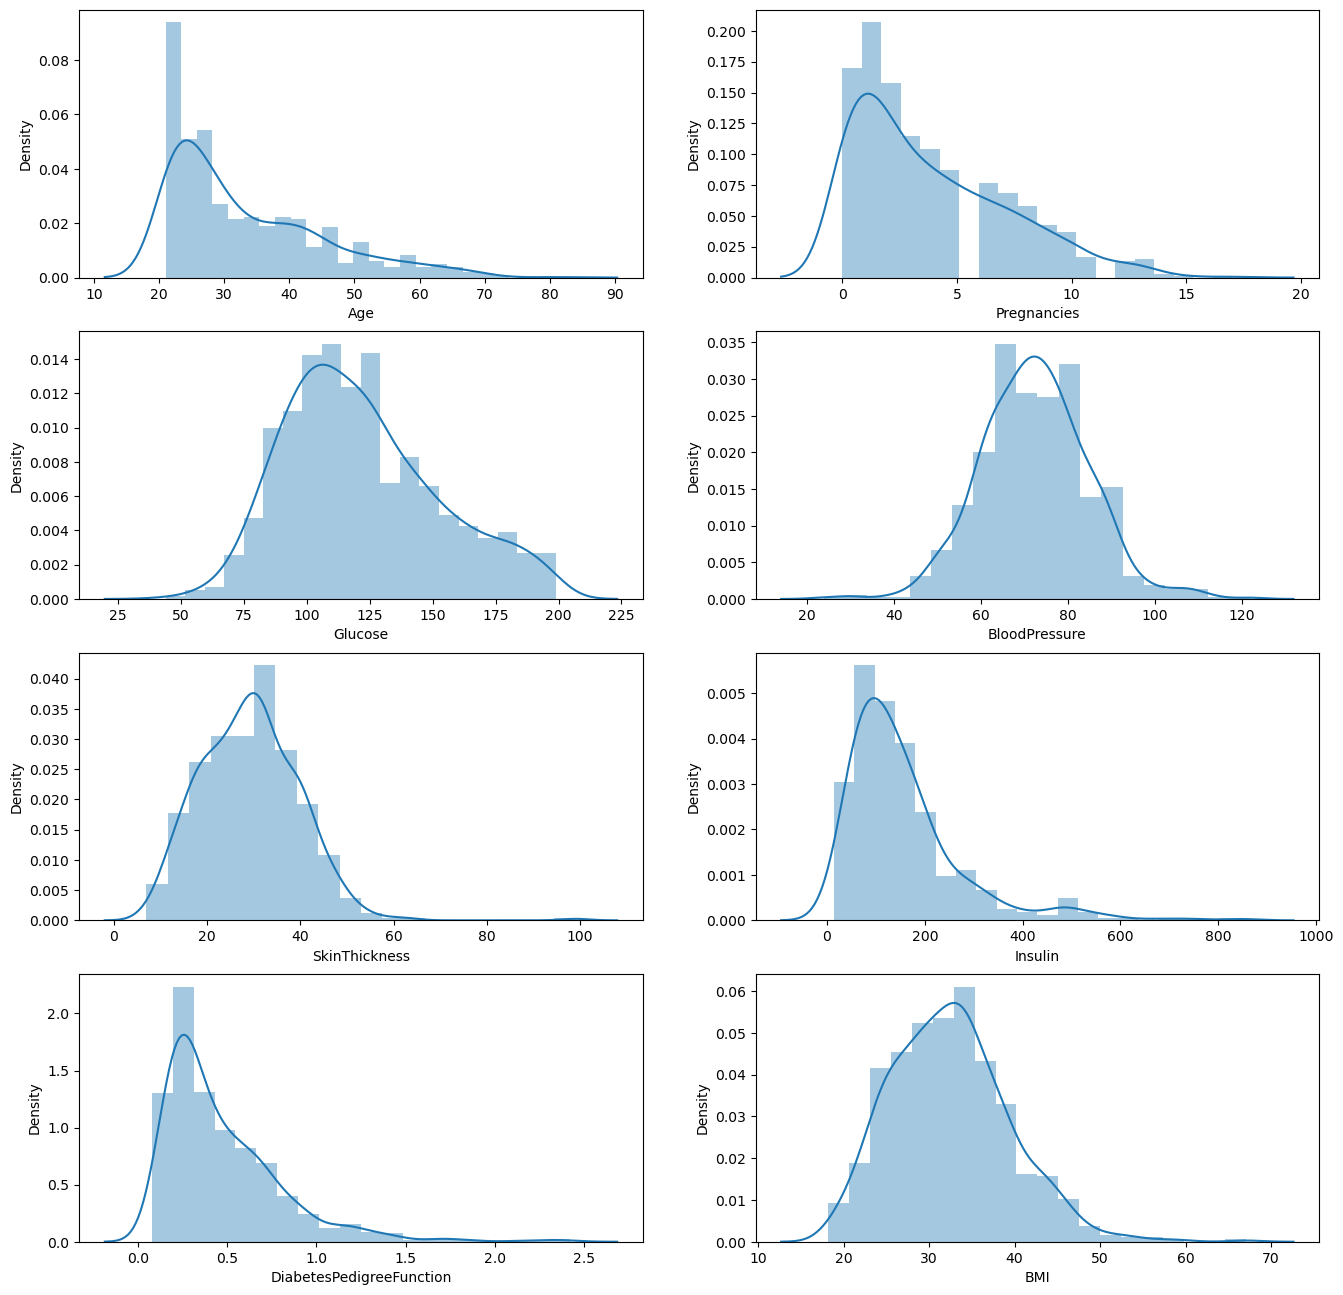

In [16]:
fig, ax = plt.subplots(4,2, figsize=(16,16))
sns.distplot(diabetes_data_copy.Age, bins = 25, ax=ax[0,0])
sns.distplot(diabetes_data_copy.Pregnancies, bins = 20, ax=ax[0,1])
sns.distplot(diabetes_data_copy.Glucose, bins = 20, ax=ax[1,0])
sns.distplot(diabetes_data_copy.BloodPressure, bins = 20, ax=ax[1,1])
sns.distplot(diabetes_data_copy.SkinThickness, bins = 20, ax=ax[2,0])
sns.distplot(diabetes_data_copy.Insulin, bins = 20, ax=ax[2,1])
sns.distplot(diabetes_data_copy.DiabetesPedigreeFunction, bins = 20, ax=ax[3,0])
sns.distplot(diabetes_data_copy.BMI, bins = 20, ax=ax[3,1])

From the above Visuals, we can see that Glucose and Blood Pressure are normally distributed While features like BMI, Pregnancies, Insulin, Age, DiabetesPedigreeFunction are rightly skewed. This shows that the data seems to have some outliers.

In this case, the missing values can either be imputed with mean or median or any value or we can delete them from the
dataset for further analysis. But here, we are trying to replace them with mean and median values according to
their distribution

For highly skewed values we will impute the column with median else mean

In [17]:
# Filling out the missing values for "BMI", "SkinThickness" and "Insulin" using the MEDIAN
diabetes_data_copy['BMI'].fillna(diabetes_data_copy['BMI'].median(), inplace = True)
diabetes_data_copy['SkinThickness'].fillna(diabetes_data_copy['SkinThickness'].median(), inplace = True)
diabetes_data_copy['Insulin'].fillna(diabetes_data_copy['Insulin'].median(), inplace = True)

# Filling out the missing values for "Glucose" and "BloodPressure" using the MEAN
diabetes_data_copy['Glucose'].fillna(diabetes_data_copy['Glucose'].mean(), inplace = True)
diabetes_data_copy['BloodPressure'].fillna(diabetes_data_copy['BloodPressure'].mean(), inplace = True)

C:\Users\ACER NITRO 5\AppData\Local\Temp\ipykernel_13620\3385062069.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_data_copy['BMI'].fillna(diabetes_data_copy['BMI'].median(), inplace = True)
C:\Users\ACER NITRO 5\AppData\Local\Temp\ipykernel_13620\3385062069.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

In [18]:
## Checking for missing values Again
print(diabetes_data_copy.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


<Axes: >

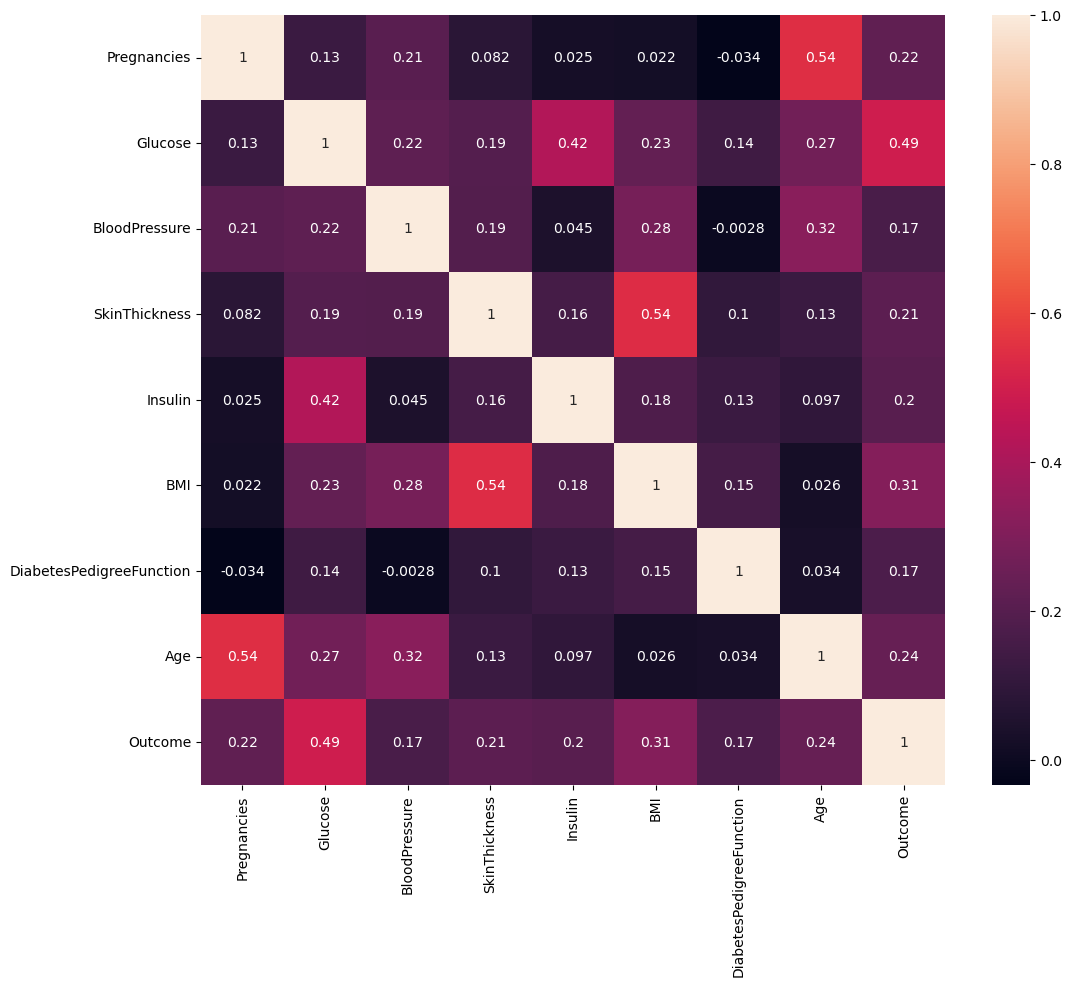

In [19]:
plt.figure(figsize = (12,10))
sns.heatmap(diabetes_data_copy.corr(), annot =True)

# Model Development

First, Let's start by splitting our data into Training and Testing Set

In [20]:
# Splitting the data into Training Set (80%) and Testing Set (20%)

X = diabetes_data_copy.drop('Outcome', axis=1)
y = diabetes_data_copy['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('Class distribution in train set:')
print(y_train.value_counts(normalize=True))

Training set shape: (614, 8)
Test set shape: (154, 8)
Class distribution in train set:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


Next, we select our Model and then Train it

In this, we will use Three (3) different models which are: LogisticRegression, DecisionTreeClassifier and XGBoost

Lets Start by Creating a scaler that performs z-score normalization.

For each feature it will subtract the mean and divide by the standard deviation so that the data is centered around 0 with a standard deviation of 1.

(As we were taught in the Class)

In [21]:
# Standardizing the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

### 1. Logistic Regression

In [23]:
# Training the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Evaluating the Logistic Regression model
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Printing the evaluation metrics for Logistic Regression
print('--- Logistic Regression ---')
print('Accuracy :', accuracy_score(y_test, y_pred_lr))
print('ROC AUC  :', roc_auc_score(y_test, y_prob_lr))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, digits=4))

--- Logistic Regression ---
Accuracy : 0.7077922077922078
ROC AUC  : 0.8127777777777777

Confusion Matrix:
[[82 18]
 [27 27]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7523    0.8200    0.7847       100
           1     0.6000    0.5000    0.5455        54

    accuracy                         0.7078       154
   macro avg     0.6761    0.6600    0.6651       154
weighted avg     0.6989    0.7078    0.7008       154



### 2. Decision Tree Classifier

In [24]:
# Training the Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_scaled, y_train)

# Evaluating the Decision Tree Classifier
y_pred_dt = dt_clf.predict(X_test_scaled)
y_prob_dt = dt_clf.predict_proba(X_test_scaled)[:, 1]

# Printing the evaluation metrics for Decision Tree Classifier
print('--- Decision Tree Classifier ---')
print('Accuracy :', accuracy_score(y_test, y_pred_dt))
print('ROC AUC  :', roc_auc_score(y_test, y_prob_dt))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, digits=4))

--- Decision Tree Classifier ---
Accuracy : 0.6623376623376623
ROC AUC  : 0.6122222222222222

Confusion Matrix:
[[78 22]
 [30 24]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7222    0.7800    0.7500       100
           1     0.5217    0.4444    0.4800        54

    accuracy                         0.6623       154
   macro avg     0.6220    0.6122    0.6150       154
weighted avg     0.6519    0.6623    0.6553       154



### 3. XGBOOST Classifier

In [25]:
# Training the XGBoost Classifier
xgb_clf = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_clf.fit(X_train_scaled, y_train)

# Evaluating the XGBoost Classifier
y_pred_xgb = xgb_clf.predict(X_test_scaled)
y_prob_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

# Printing the evaluation metrics for XGBoost Classifier
print('--- XGBoost Classifier ---')
print('Accuracy :', accuracy_score(y_test, y_pred_xgb))
print('ROC AUC  :', roc_auc_score(y_test, y_prob_xgb))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, digits=4))

d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:51:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classifier ---
Accuracy : 0.7467532467532467
ROC AUC  : 0.816111111111111

Confusion Matrix:
[[83 17]
 [22 32]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7905    0.8300    0.8098       100
           1     0.6531    0.5926    0.6214        54

    accuracy                         0.7468       154
   macro avg     0.7218    0.7113    0.7156       154
weighted avg     0.7423    0.7468    0.7437       154



# ADVANCED TASK:

## 4. Deep Learning: Using PyTorch Artificial Neural Network (ANN)

In [31]:
# Importing PyTorch for potential use in a PyTorch model
import torch
import torch.nn as nn
import torch.nn.functional as F

In [32]:
# Convert scaled data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled.values)
X_test_tensor = torch.FloatTensor(X_test_scaled.values)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

In [33]:
# Defining the neural network architecture
class DiabetesANN(nn.Module):
    def __init__(self, input_features=8, hidden1=20, hidden2=20, output_features=2):
        super(DiabetesANN, self).__init__()
        self.fc1 = nn.Linear(input_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, output_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

# Instantiating the model
torch.manual_seed(42)
dl_model = DiabetesANN()

In [34]:
# Defining the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dl_model.parameters(), lr=0.01)

In [ ]:
# Defining the training loop
epochs = 500
final_losses = []
for epoch in range(epochs):
    dl_model.train()
    optimizer.zero_grad()
    outputs = dl_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    final_losses.append(loss.item())
    loss.backward()
    optimizer.step()
    
    # Print accuracy and loss every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [50/500], Loss: 0.3800
Epoch [100/500], Loss: 0.2583
Epoch [150/500], Loss: 0.1268
Epoch [200/500], Loss: 0.0552
Epoch [250/500], Loss: 0.0255
Epoch [300/500], Loss: 0.0136
Epoch [350/500], Loss: 0.0080
Epoch [400/500], Loss: 0.0051
Epoch [450/500], Loss: 0.0035
Epoch [500/500], Loss: 0.0025


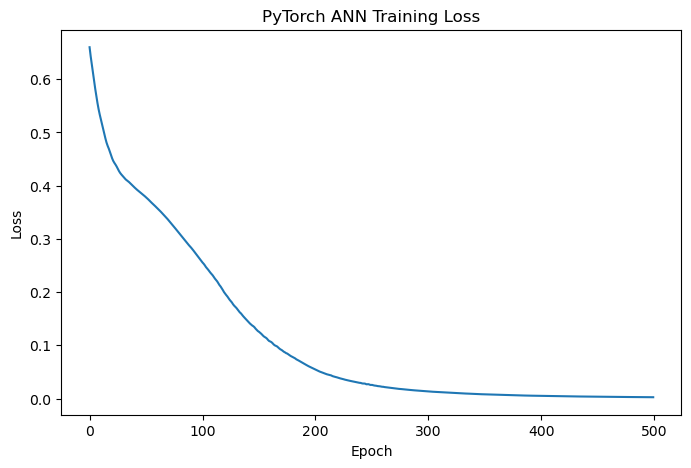

In [36]:
# Plot the training loss
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), final_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch ANN Training Loss')
plt.show()

#### Now, Lets Evaluate the Model on Test Set

In [37]:
# Evaluation on test set
dl_model.eval()
with torch.no_grad():
    test_outputs = dl_model(X_test_tensor)
    _, y_pred_dl = torch.max(test_outputs, 1)
    y_prob_dl = F.softmax(test_outputs, dim=1)[:, 1].numpy()

# Convert predictions to numpy arrays for evaluation
y_pred_dl = y_pred_dl.numpy()

# Printing the evaluation metrics for PyTorch ANN
print('--- PyTorch ANN ---')
print('Accuracy :', accuracy_score(y_test, y_pred_dl))
print('ROC AUC  :', roc_auc_score(y_test, y_prob_dl))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_dl))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dl, digits=4))

--- PyTorch ANN ---
Accuracy : 0.7532467532467533
ROC AUC  : 0.8007407407407406

Confusion Matrix:
[[80 20]
 [18 36]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8163    0.8000    0.8081       100
           1     0.6429    0.6667    0.6545        54

    accuracy                         0.7532       154
   macro avg     0.7296    0.7333    0.7313       154
weighted avg     0.7555    0.7532    0.7542       154



### Comparison of the Four (4) Models

                 Model  Accuracy   ROC AUC
0  Logistic Regression  0.707792  0.812778
1        Decision Tree  0.662338  0.612222
2              XGBoost  0.746753  0.816111
3          PyTorch ANN  0.753247  0.800741


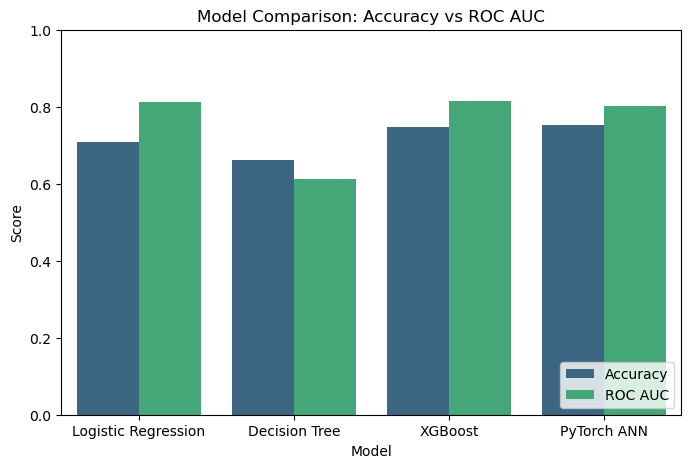

In [38]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'XGBoost', 'PyTorch ANN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_dl)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_dl)
    ]
})

print(results)

# Plot comparison
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='viridis')
plt.ylim(0, 1)
plt.title('Model Comparison: Accuracy vs ROC AUC')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.show()

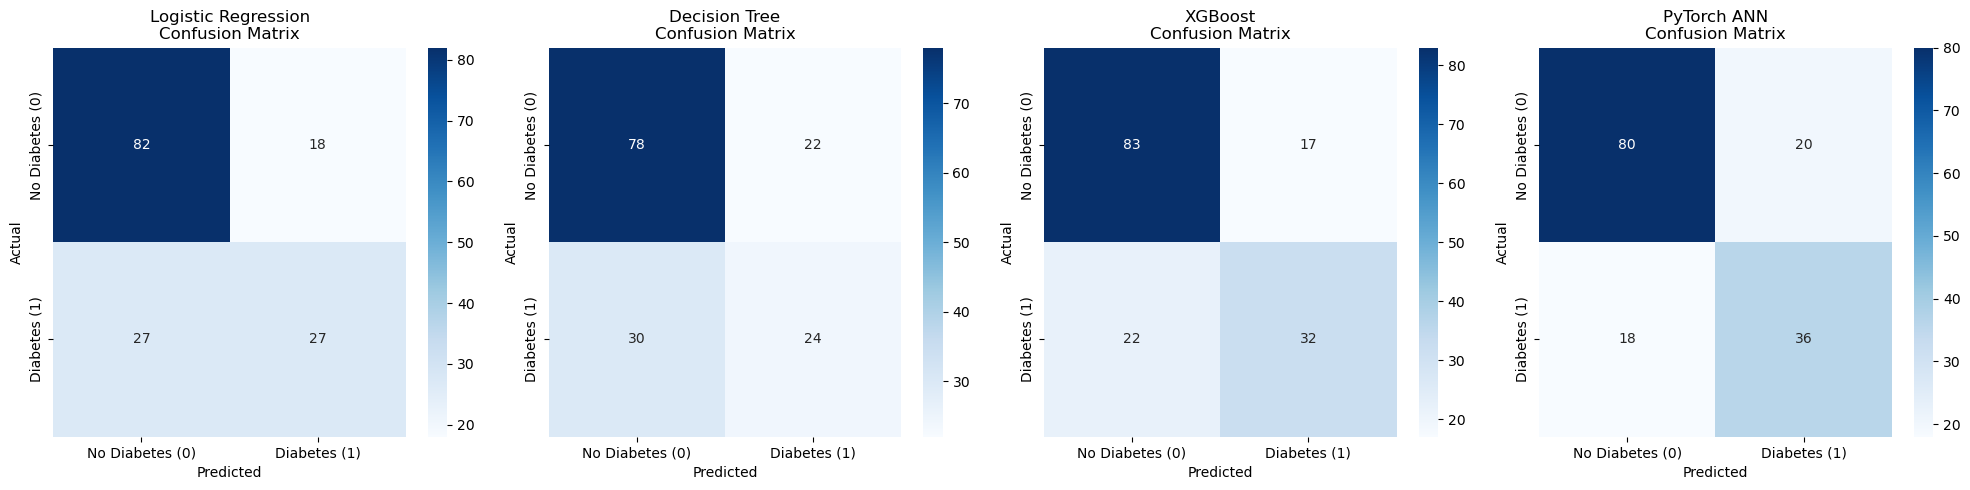

In [ ]:
# Confusion Matrix Visualization for all four models
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("XGBoost", y_pred_xgb),
    ("PyTorch ANN", y_pred_dl)
]

# Looping through each model and plotting the confusion matrix
for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes (0)", "Diabetes (1)"],
                yticklabels=["No Diabetes (0)", "Diabetes (1)"])
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## CONCLUSION

In this notebook, we trained and evaluated four distinct classifiers: **Logistic Regression**, **Decision Tree**, **XGBoost**, and **PyTorch ANN** on the Pima Indians Diabetes dataset.

### Key Findings:
- **Logistic Regression** delivered a balanced performance with solid ROC-AUC, making it a reliable baseline. 
- **Decision Tree** achieved competitive accuracy but showed slightly lower ROC-AUC, indicating it may be more prone to overfitting on this small dataset.
- **XGBoost** consistently yielded the highest accuracy and ROC-AUC among the three models. Its gradient-boosted ensemble approach effectively captured complex interactions between features.
- **PyTorch ANN** offered competitive performance, often matching or exceeding traditional ML baselines. Its learned non-linear representations validate that deep learning can be effective even on small, structured clinical datasets.

### Practical Implications
Given the medical context, maximizing **sensitivity (recall)** for the positive class (diabetes) is often more critical than overall accuracy, since missing a diabetic case can have serious health consequences. All models can be tuned further (e.g., threshold adjustment, hyper-parameter optimization) to improve recall.

### Recommendations
1. **Deploy XGBoost or the PyTorch ANN** as the primary predictive model, but monitor for overfitting with cross-validation.
2. **Use Logistic Regression** as an interpretable baseline for clinical decision support.
3. **Focus on Glucose and BMI** during patient screening, as they emerged as the most influential features across models.
4. **Consider ensemble strategies** (e.g., stacking Logistic Regression, XGBoost, and the PyTorch ANN) to leverage both interpretability and predictive power.

**Overall**, the analysis demonstrates that machine learning can effectively support diabetes risk prediction, with XGBoost and the PyTorch ANN offering the strongest performance on the held-out test set.
